# Topic 2: t-SNE — Theory

## 1. What is t-SNE?

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a dimensionality-reduction algorithm mainly used to **visualize high-dimensional data**.

Its main goal is different from PCA.

PCA tries to preserve **maximum variance**:

$$
\text{High-dimensional data}
\rightarrow
\text{directions of maximum variance}
$$

t-SNE tries to preserve **local relationships between nearby points**:

$$
\text{High-dimensional data}
\rightarrow
\text{similar points stay close}
$$

For example:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

so that we can visualize the data.

---

# 2. Intuition

Imagine we have 6 points in high-dimensional space.

Some points are very similar:

```text
A ─ B ─ C

D ─ E ─ F
```

The important information is that:

* A, B, C are neighbors
* D, E, F are neighbors
* The two groups are relatively different

t-SNE tries to create a low-dimensional representation where these neighborhood relationships remain similar:

```text
       B
     A   C


       E
     D   F
```

So the basic idea is:

> **Points that are close in the original space should generally remain close in the new space.**

---

# 3. Why Do We Need t-SNE?

Suppose every data point has:

$$
100\text{ features}
$$

We cannot directly visualize that.

We could use PCA:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

But PCA focuses on **global linear variance**.

Sometimes the important structure is about **local neighborhoods** rather than overall variance.

t-SNE is designed specifically to preserve those local relationships.

---

# 4. PCA vs t-SNE

This distinction is extremely important.

### PCA

PCA asks:

> Which directions contain the maximum variance?

$$
\text{Maximum Variance}
\rightarrow
\text{Principal Components}
$$

### t-SNE

t-SNE asks:

> Which points are close to each other, and can I preserve those neighborhood relationships?

$$
\text{Local Similarity}
\rightarrow
\text{Low-dimensional Embedding}
$$

Therefore:

| PCA                                     | t-SNE                                                  |
| --------------------------------------- | ------------------------------------------------------ |
| Linear                                  | Nonlinear                                              |
| Preserves variance                      | Preserves local neighborhoods                          |
| Components have mathematical directions | Embedding dimensions usually don't have direct meaning |
| Useful for reduction and preprocessing  | Mainly useful for visualization                        |
| Deterministic in its basic form         | Optimization/random initialization can affect result   |

---

# 5. High-Dimensional Space

Suppose one data point has 3 features:

$$
x=
\begin{bmatrix}
2\\
4\\
5
\end{bmatrix}
$$

Another point:

$$
y=
\begin{bmatrix}
3\\
4\\
5
\end{bmatrix}
$$

We can calculate the distance between them.

For Euclidean distance:

$$
d(x,y)
=
\sqrt{
(2-3)^2+
(4-4)^2+
(5-5)^2
}
$$

$$
=
\sqrt{
(-1)^2+0^2+0^2
}
$$

$$
=
\sqrt{1}
$$

$$
=1
$$

So these points are close.

t-SNE starts by measuring these kinds of relationships between points.

---

# 6. Local vs Global Structure

This is one of the most important concepts in t-SNE.

## Local Structure

Local structure means:

> Who are my nearest neighbors?

For example:

```text
A
 \
  B
   \
    C
```

If A and B are very close, t-SNE tries to keep them close.

---

## Global Structure

Global structure means:

> How are all groups positioned relative to each other?

For example:

```text
Cluster A             Cluster B
● ● ●                 ● ● ●
● ● ●                 ● ● ●
```

t-SNE is much more focused on preserving the **local neighborhood structure** than exact global distances between clusters.

Therefore, if two clusters appear far apart in a t-SNE plot, you should **not automatically interpret the distance between the clusters as a meaningful quantitative distance**.

---

# 7. How t-SNE Thinks About Similarity

Suppose we have points:

$$
A,\ B,\ C,\ D
$$

Suppose A is very close to B but far from D.

We want:

$$
P(B\mid A)
>
P(D\mid A)
$$

In simple words:

> The probability that B is a neighbor of A should be much higher than the probability that D is a neighbor of A.

t-SNE converts distances into **probabilities of similarity**.

So the first major idea is:

$$
\boxed{
\text{Distance}
\rightarrow
\text{Similarity Probability}
}
$$

---

# 8. Why Use Probabilities?

Suppose the distances from point A are:

| Point | Distance from A |
| ----- | --------------: |
| B     |               1 |
| C     |               2 |
| D     |               5 |

We intuitively want:

$$
B
\rightarrow
\text{very similar}
$$

$$
C
\rightarrow
\text{somewhat similar}
$$

$$
D
\rightarrow
\text{not very similar}
$$

Instead of simply storing distances, t-SNE converts them into probabilities:

$$
P(B\mid A)
>
P(C\mid A)
>
P(D\mid A)
$$

Now we have a probability distribution describing the neighborhood around A.

---

# 9. Gaussian Distribution

In the high-dimensional space, t-SNE uses a **Gaussian distribution** to convert distances into similarities.

The basic Gaussian function is:

$$
f(d)
=
e^{-\frac{d^2}{2\sigma^2}}
$$

where:

* \(d\) = distance between two points
* \(\sigma\) = controls the width of the neighborhood
* \(e\) = mathematical constant

The important behavior is:

$$
d\uparrow
\rightarrow
f(d)\downarrow
$$

So:

> The farther two points are, the smaller their similarity becomes.

---

# 10. Small Example

Suppose:

$$
\sigma=1
$$

and two points have distance:

$$
d=1
$$

Then:

$$
f(1)
=
e^{-\frac{1^2}{2(1)^2}}
$$

$$
=
e^{-1/2}
$$

Approximately:

$$
f(1)\approx0.607
$$

Now suppose:

$$
d=2
$$

Then:

$$
f(2)
=
e^{-\frac{2^2}{2}}
$$

$$
=
e^{-2}
$$

Approximately:

$$
f(2)\approx0.135
$$

So:

$$
0.607>0.135
$$

Therefore the closer point receives a much higher similarity.

---

# 11. Conditional Probability

t-SNE converts these similarities into probabilities.

For point \(i\), the probability of choosing point \(j\) as its neighbor is:

$$
p_{j|i}
=
\frac{
\exp\left(
-\frac{\|x_i-x_j\|^2}{2\sigma_i^2}
\right)
}{
\sum_{k\ne i}
\exp\left(
-\frac{\|x_i-x_k\|^2}{2\sigma_i^2}
\right)
}
$$

### What does this mean?

The numerator measures how similar \(i\) and \(j\) are.

The denominator normalizes the similarities so that the probabilities add up to 1.

Therefore:

$$
\sum_{j\ne i}p_{j|i}=1
$$

for each point \(i\).

---

# 12. Why Does Each Point Have Its Own \(\sigma_i\)?

Different regions of a dataset can have different densities.

Imagine:

```text
Dense region:

●●●
●●●
●●●


Sparse region:

●       ●       ●
```

A fixed neighborhood size wouldn't work equally well in both regions.

So t-SNE can use a different Gaussian width:

$$
\sigma_i
$$

for each point.

This allows the algorithm to adapt to local density.

---

# 13. Perplexity

This leads to an important t-SNE parameter:

$$
\boxed{\text{Perplexity}}
$$

Perplexity roughly controls:

> **How many neighboring points each point effectively considers.**

It is related to the entropy of the probability distribution.

The entropy is:

$$
H(P_i)
=
-\sum_j p_{j|i}\log_2(p_{j|i})
$$

Perplexity is then:

$$
\text{Perplexity}(P_i)
=
2^{H(P_i)}
$$

You don't need to memorize the derivation yet.

The intuition is more important:

$$
\boxed{
\text{Perplexity}
\approx
\text{effective neighborhood size}
}
$$

For example, a perplexity around 30 means t-SNE is roughly considering a neighborhood of that scale for each point.

---

# 14. What Happens After High-Dimensional Similarities?

So far we have:

$$
\text{High-dimensional Data}
\rightarrow
\text{Distances}
\rightarrow
\text{Similarities}
\rightarrow
P
$$

where \(P\) represents the high-dimensional similarity relationships.

But we still need to create the low-dimensional representation.

Suppose we want 2D.

t-SNE creates new points:

$$
y_1,y_2,\ldots,y_n
$$

where each:

$$
y_i\in\mathbb{R}^2
$$

The goal is to arrange these points so that their low-dimensional similarities resemble the original high-dimensional similarities.

---

# 15. Why Does t-SNE Use a Student's t-Distribution?

This is the key idea behind the **"t"** in t-SNE.

In the low-dimensional space, t-SNE uses a **Student's t-distribution** instead of a Gaussian distribution.

The simplified similarity function is:

$$
q_{ij}
=
\frac{
(1+\|y_i-y_j\|^2)^{-1}
}{
\sum_{k\ne l}
(1+\|y_k-y_l\|^2)^{-1}
}
$$

The important difference is that the Student's t-distribution has **heavier tails** than the Gaussian.

---

# 16. Why Heavy Tails?

This solves an important problem called the **crowding problem**.

Imagine many high-dimensional points need to be represented in 2D.

There isn't enough space to preserve all their relationships perfectly.

Points can become crowded together.

The heavier-tailed Student's t-distribution allows dissimilar points to spread farther apart in the low-dimensional space.

So:

$$
\boxed{
\text{Heavy tails}
\rightarrow
\text{more room for dissimilar points}
}
$$

This helps create visually separated clusters.

---

# 17. Comparing the Two Distributions

High-dimensional space:

$$
p_{ij}
\rightarrow
\text{Gaussian-based similarity}
$$

Low-dimensional space:

$$
q_{ij}
\rightarrow
\text{Student's t-based similarity}
$$

Then t-SNE tries to make:

$$
P\approx Q
$$

In other words:

> Make the low-dimensional neighborhood relationships resemble the original high-dimensional neighborhood relationships.

---

# 18. KL Divergence

But how do we measure whether \(P\) and \(Q\) are similar?

t-SNE uses **Kullback-Leibler divergence**.

The objective is:

$$
KL(P\parallel Q)
=
\sum_i\sum_j
p_{ij}
\log
\left(
\frac{p_{ij}}{q_{ij}}
\right)
$$

The algorithm tries to **minimize** this value.

So:

$$
\boxed{
\text{Minimize }KL(P\parallel Q)
}
$$

means:

> Make the low-dimensional similarities \(Q\) resemble the original similarities \(P\).

---

# 19. Intuition Behind KL Divergence

Suppose:

$$
p_{ij}=0.8
$$

but:

$$
q_{ij}=0.1
$$

Then t-SNE is saying:

> "These two points were very similar originally, but you've placed them too far apart."

The optimization will try to move them closer.

Conversely, if two points were not neighbors originally but become very close in the embedding, the optimization can push them apart.

So the optimization tries to preserve the important neighborhood relationships.

---

# 20. Complete t-SNE Flow

Now we can see the entire algorithm conceptually:

$$
\text{High-dimensional Data}
\rightarrow
\text{Calculate Pairwise Distances}
$$

$$
\rightarrow
\text{Convert Distances to Similarity Probabilities}
$$

$$
\rightarrow
P
$$

$$
\rightarrow
\text{Initialize Low-dimensional Points}
$$

$$
\rightarrow
\text{Calculate Low-dimensional Similarities}
$$

$$
\rightarrow
Q
$$

$$
\rightarrow
\text{Calculate }KL(P\parallel Q)
$$

$$
\rightarrow
\text{Optimize}
$$

$$
\rightarrow
\text{Low-dimensional Embedding}
$$

---

# 21. The Most Important Mental Model

Don't think of t-SNE as:

> "Find the directions of maximum variance."

That's PCA.

Think:

> **"Take the neighborhood relationships in high-dimensional space and arrange points in 2D so those relationships are preserved as much as possible."**

So:

$$
\boxed{
\text{PCA}
\rightarrow
\text{Maximum Variance}
}
$$

$$
\boxed{
\text{t-SNE}
\rightarrow
\text{Preserve Local Neighborhoods}
}
$$

And the core mathematical flow is:

$$
\boxed{
\text{Distances}
\rightarrow
P
\rightarrow
Q
\rightarrow
KL(P\parallel Q)
\rightarrow
\text{Optimization}
}
$$


# Topic 3: Pairwise Distances

## 1. What Does Pairwise Distance Mean?

### What it means

In t-SNE, we need to know **how close or far every pair of data points is**.

For example, if we have:

$$
A=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

and:

$$
B=
\begin{bmatrix}
2\\
3
\end{bmatrix}
$$

we calculate the distance between A and B.

This is called a **pairwise distance** because we calculate distances between pairs of points.

---

# 2. Why Does t-SNE Need It?

t-SNE wants to preserve local neighborhoods.

To know which points are neighbors, it first needs to know:

> **Which points are close to each other?**

So:

$$
\text{Data}
\rightarrow
\text{Pairwise Distances}
\rightarrow
\text{Identify Similar/Close Points}
$$

Later, these distances will be converted into **similarity probabilities**.

---

# 3. Euclidean Distance

The most common distance is Euclidean distance.

For two points:

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

and:

$$
y=
\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}
$$

the Euclidean distance is:

$$
d(x,y)
=
\sqrt{
(x_1-y_1)^2+
(x_2-y_2)^2
}
$$

For \(d\) dimensions:

$$
d(x,y)
=
\sqrt{
\sum_{k=1}^{d}
(x_k-y_k)^2
}
$$

### Meaning

* \(x_k\) = coordinate of point \(x\) in dimension \(k\)
* \(y_k\) = coordinate of point \(y\) in dimension \(k\)
* \(d\) = number of dimensions

---

# 4. Small Example

Consider:

$$
A=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

and:

$$
B=
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$

Calculate the difference in the first dimension:

$$
1-4=-3
$$

Second dimension:

$$
2-6=-4
$$

Square them:

$$
(-3)^2=9
$$

$$
(-4)^2=16
$$

Add:

$$
9+16=25
$$

Take the square root:

$$
d(A,B)
=
\sqrt{25}
$$

$$
\boxed{d(A,B)=5}
$$

So A and B are 5 units apart.

---

# 5. Pairwise Distances for Multiple Points

Suppose we have three points:

$$
A=
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

$$
B=
\begin{bmatrix}
2\\
2
\end{bmatrix}
$$

$$
C=
\begin{bmatrix}
5\\
5
\end{bmatrix}
$$

We need to calculate:

$$
d(A,B)
$$

$$
d(A,C)
$$

$$
d(B,C)
$$

---

## Distance A → B

$$
d(A,B)
=
\sqrt{
(1-2)^2+
(1-2)^2
}
$$

$$
=
\sqrt{
1+1
}
$$

$$
=\sqrt{2}
$$

---

## Distance A → C

$$
d(A,C)
=
\sqrt{
(1-5)^2+
(1-5)^2
}
$$

$$
=
\sqrt{
16+16
}
$$

$$
=\sqrt{32}
$$

$$
=4\sqrt{2}
$$

---

## Distance B → C

$$
d(B,C)
=
\sqrt{
(2-5)^2+
(2-5)^2
}
$$

$$
=
\sqrt{
9+9
}
$$

$$
=\sqrt{18}
$$

$$
=3\sqrt{2}
$$

Therefore:

$$
d(A,B)=\sqrt{2}
$$

$$
d(B,C)=3\sqrt{2}
$$

$$
d(A,C)=4\sqrt{2}
$$

So:

$$
A
\leftrightarrow
B
$$

are the closest pair.

---

# 6. Distance Matrix

Instead of storing every distance separately, we can organize them into a **distance matrix**.

For our three points:

$$
D=
\begin{bmatrix}
0&\sqrt{2}&4\sqrt{2}\\
\sqrt{2}&0&3\sqrt{2}\\
4\sqrt{2}&3\sqrt{2}&0
\end{bmatrix}
$$

Each entry \(D_{ij}\) represents:

$$
D_{ij}=d(x_i,x_j)
$$

For example:

$$
D_{12}=\sqrt{2}
$$

means the distance between A and B is \(\sqrt{2}\).

And:

$$
D_{13}=4\sqrt{2}
$$

means the distance between A and C is \(4\sqrt{2}\).

---

# 7. Why Are the Diagonal Values Zero?

Look at:

$$
D=
\begin{bmatrix}
0&\sqrt{2}&4\sqrt{2}\\
\sqrt{2}&0&3\sqrt{2}\\
4\sqrt{2}&3\sqrt{2}&0
\end{bmatrix}
$$

The diagonal is:

$$
D_{11}=0
$$

$$
D_{22}=0
$$

$$
D_{33}=0
$$

That's because the distance from a point to itself is zero:

$$
d(A,A)=0
$$

---

# 8. Why Is the Matrix Symmetric?

Notice:

$$
D_{12}=D_{21}
$$

because:

$$
d(A,B)=d(B,A)
$$

Therefore:

$$
D=
D^T
$$

For example:

$$
D=
\begin{bmatrix}
0&\sqrt{2}&4\sqrt{2}\\
\sqrt{2}&0&3\sqrt{2}\\
4\sqrt{2}&3\sqrt{2}&0
\end{bmatrix}
$$

The upper-right and lower-left values are the same.

---

# 9. What Does t-SNE Do With These Distances?

This is the important part.

Suppose:

$$
d(A,B)=\sqrt{2}
$$

and:

$$
d(A,C)=4\sqrt{2}
$$

We know:

$$
d(A,B)<d(A,C)
$$

Therefore:

> B is more similar to A than C is.

t-SNE converts this distance information into probabilities.

Conceptually:

$$
\text{Small Distance}
\rightarrow
\text{High Similarity}
\rightarrow
\text{High Probability}
$$

and:

$$
\text{Large Distance}
\rightarrow
\text{Low Similarity}
\rightarrow
\text{Low Probability}
$$

This is the next step.

---

# 10. Important: Distance Is Not Yet Similarity

At this stage, we have only calculated:

$$
d(x_i,x_j)
$$

A smaller distance means points are closer.

But t-SNE ultimately needs probabilities such as:

$$
p_{j|i}
$$

So we still need to transform:

$$
\boxed{
\text{Distance}
\rightarrow
\text{Similarity Probability}
}
$$

This is done using a Gaussian distribution in the high-dimensional space.

---

# 11. Complete Flow So Far

We now have:

$$
\text{High-dimensional Data}
\rightarrow
\text{Pairwise Distances}
\rightarrow
\text{Distance Matrix}
\rightarrow
\text{Similarity Probabilities}
$$

For example:

$$
A,B,C
\rightarrow
D
\rightarrow
\text{Gaussian Similarities}
\rightarrow
P
$$


# Topic 4: Similarity Probabilities

## 1. What Does Similarity Probability Mean?

In t-SNE, distance alone isn't enough.

We want to convert:

$$
\text{Distance between points}
\rightarrow
\text{Probability that they are neighbors}
$$

A close point should get a **high probability**, while a far point should get a **low probability**.

---

## 2. Why Do We Need Probabilities?

Suppose point \(A\) has three other points around it:

$$
d(A,B)=1
$$

$$
d(A,C)=2
$$

$$
d(A,D)=5
$$

Intuitively:

$$
B
\rightarrow
\text{most similar to A}
$$

$$
C
\rightarrow
\text{less similar}
$$

$$
D
\rightarrow
\text{least similar}
$$

t-SNE represents this using probabilities:

$$
p_{B|A}>p_{C|A}>p_{D|A}
$$

The probabilities describe the **neighborhood of A**.

---

# 3. Converting Distance into Similarity

t-SNE uses a Gaussian-based similarity.

Before normalization, the similarity is:

$$
s_{ij}
=
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
$$

### Meaning of each term

* \(x_i\) = point \(i\)
* \(x_j\) = point \(j\)
* \(\|x_i-x_j\|\) = distance between them
* \(\sigma_i\) = width of the neighborhood around point \(i\)
* \(\exp\) = exponential function

The important relationship is:

$$
\text{Distance}\uparrow
\rightarrow
\text{Similarity}\downarrow
$$

---

# 4. Small Numerical Example

Suppose:

$$
\sigma_i=1
$$

and point A has two other points:

$$
d(A,B)=1
$$

$$
d(A,C)=2
$$

### Similarity between A and B

$$
s_{AB}
=
\exp
\left(
-\frac{1^2}{2(1)^2}
\right)
$$

$$
=
\exp(-0.5)
$$

Approximately:

$$
s_{AB}\approx0.607
$$

### Similarity between A and C

$$
s_{AC}
=
\exp
\left(
-\frac{2^2}{2(1)^2}
\right)
$$

$$
=
\exp(-2)
$$

Approximately:

$$
s_{AC}\approx0.135
$$

Therefore:

$$
0.607>0.135
$$

So B is much more similar to A than C is.

---

# 5. Convert Similarities into Probabilities

The similarities aren't probabilities yet.

We normalize them:

$$
p_{j|i}
=
\frac{
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
}{
\sum_{k\ne i}
\exp
\left(
-\frac{\|x_i-x_k\|^2}
{2\sigma_i^2}
\right)
}
$$

This ensures that all probabilities around point \(i\) add up to 1:

$$
\sum_{j\ne i}p_{j|i}=1
$$

---

# 6. Complete Numerical Example

Suppose A has two possible neighbors:

$$
d(A,B)=1
$$

$$
d(A,C)=2
$$

and:

$$
\sigma_A=1
$$

We already calculated:

$$
s_{AB}\approx0.607
$$

and:

$$
s_{AC}\approx0.135
$$

Now add them:

$$
0.607+0.135=0.742
$$

### Probability of B given A

$$
p_{B|A}
=
\frac{0.607}{0.742}
$$

$$
p_{B|A}\approx0.818
$$

### Probability of C given A

$$
p_{C|A}
=
\frac{0.135}{0.742}
$$

$$
p_{C|A}\approx0.182
$$

Check:

$$
0.818+0.182=1
$$

Therefore:

$$
\boxed{p_{B|A}\approx0.818}
$$

and:

$$
\boxed{p_{C|A}\approx0.182}
$$

So t-SNE considers B much more likely to be a neighbor of A.

---

# 7. Why Is It Called Conditional Probability?

Notice the notation:

$$
p_{j|i}
$$

Read this as:

> **Probability of point \(j\) being a neighbor, given point \(i\).**

For example:

$$
p_{B|A}
$$

means:

> Probability of B being a neighbor of A.

The relationship is directional in this representation:

$$
p_{B|A}
\neq
p_{A|B}
$$

because A and B can have different local neighborhood widths:

$$
\sigma_A
\neq
\sigma_B
$$

---

# 8. Why Does Each Point Have Its Own Probability Distribution?

Suppose we have four points:

$$
A,\ B,\ C,\ D
$$

For A, we create:

$$
P_A=
\begin{bmatrix}
p_{B|A}\\
p_{C|A}\\
p_{D|A}
\end{bmatrix}
$$

For B, we create another distribution:

$$
P_B=
\begin{bmatrix}
p_{A|B}\\
p_{C|B}\\
p_{D|B}
\end{bmatrix}
$$

And so on.

Thus every point gets its own neighborhood probability distribution.

---

# 9. From Conditional to Joint Probability

Eventually, t-SNE wants a symmetric relationship between points.

It therefore combines the two conditional probabilities:

$$
p_{ij}
=
\frac{
p_{j|i}+p_{i|j}
}{
2n
}
$$

where \(n\) is the number of data points.

This gives a symmetric probability:

$$
p_{ij}=p_{ji}
$$

So instead of asking only:

> How likely is B to be a neighbor of A?

we get a symmetric measure of how strongly A and B are related.

---

# 10. Intuition

The entire process is:

$$
\text{Distance}
\rightarrow
\text{Gaussian Similarity}
\rightarrow
\text{Normalize}
\rightarrow
\text{Probability}
$$

A very close point:

$$
\text{Small distance}
\rightarrow
\text{Large similarity}
\rightarrow
\text{Large probability}
$$

A distant point:

$$
\text{Large distance}
\rightarrow
\text{Small similarity}
\rightarrow
\text{Small probability}
$$

The resulting probabilities describe the **high-dimensional neighborhood structure** that t-SNE tries to preserve.


# Topic 5: Gaussian Distribution

## 1. What is the Gaussian Distribution?

The **Gaussian distribution**, also called the **normal distribution**, is used in t-SNE to convert distances between points into similarity values.

The key idea is:

> **Nearby points should have high similarity, while distant points should have low similarity.**

---

## 2. Why Does t-SNE Need It?

We already calculated distances:

$$
d(x_i,x_j)
$$

But a distance by itself doesn't tell us how strongly two points are related.

So t-SNE converts:

$$
\text{Distance}
\rightarrow
\text{Similarity}
$$

using a Gaussian function.

---

# 3. Gaussian Similarity Function

The similarity between two points is calculated as:

$$
s_{ij}
=
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
$$

### Meaning of each term

* \(x_i\) = point \(i\)
* \(x_j\) = point \(j\)
* \(\|x_i-x_j\|\) = distance between the two points
* \(\sigma_i\) = width of the Gaussian distribution around point \(i\)
* \(\exp\) = exponential function

The important part is:

$$
-\frac{d^2}{2\sigma^2}
$$

As distance increases, this value becomes more negative.

Therefore:

$$
d\uparrow
\rightarrow
s_{ij}\downarrow
$$

---

# 4. Why Square the Distance?

The formula contains:

$$
\|x_i-x_j\|^2
$$

because the Gaussian distribution depends on the **squared distance**.

For example, if:

$$
d=2
$$

then:

$$
d^2=4
$$

If:

$$
d=5
$$

then:

$$
d^2=25
$$

So large distances are penalized much more strongly.

---

# 5. Small Numerical Example

Suppose:

$$
\sigma=1
$$

Consider two points whose distance is:

$$
d=1
$$

Then:

$$
s
=
\exp
\left(
-\frac{1^2}{2(1)^2}
\right)
$$

$$
=
\exp(-0.5)
$$

Approximately:

$$
s\approx0.607
$$

Now consider a point at distance:

$$
d=2
$$

Then:

$$
s
=
\exp
\left(
-\frac{2^2}{2(1)^2}
\right)
$$

$$
=
\exp(-2)
$$

Approximately:

$$
s\approx0.135
$$

So:

$$
d=1
\rightarrow
s\approx0.607
$$

while:

$$
d=2
\rightarrow
s\approx0.135
$$

The closer point gets a much higher similarity.

---

# 6. What Happens When Distance Is Zero?

Suppose a point is compared with itself:

$$
d=0
$$

Then:

$$
s
=
\exp
\left(
-\frac{0^2}{2\sigma^2}
\right)
$$

$$
=
\exp(0)
$$

and:

$$
\exp(0)=1
$$

Therefore:

$$
\boxed{s=1}
$$

So zero distance corresponds to maximum similarity.

---

# 7. What Happens as Distance Becomes Very Large?

Suppose:

$$
d\rightarrow\infty
$$

Then:

$$
-\frac{d^2}{2\sigma^2}
\rightarrow
-\infty
$$

and:

$$
e^{-\infty}\rightarrow0
$$

Therefore:

$$
\boxed{s\rightarrow0}
$$

So:

$$
\text{Very close}
\rightarrow
\text{Similarity near 1}
$$

and:

$$
\text{Very far}
\rightarrow
\text{Similarity near 0}
$$

---

# 8. Role of \(\sigma\)

The parameter \(\sigma\) controls **how quickly similarity decreases with distance**.

Think of \(\sigma\) as controlling the width of the neighborhood.

---

## Small \(\sigma\)

Suppose:

$$
\sigma=0.5
$$

Even a moderately distant point will get a small similarity.

So the algorithm focuses strongly on very close neighbors.

Conceptually:

$$
\text{Small }\sigma
\rightarrow
\text{Narrow neighborhood}
$$

---

## Large \(\sigma\)

Suppose:

$$
\sigma=5
$$

Points can be farther away while still receiving meaningful similarity.

Conceptually:

$$
\text{Large }\sigma
\rightarrow
\text{Wider neighborhood}
$$

---

# 9. Numerical Comparison of \(\sigma\)

Suppose:

$$
d=2
$$

### Case 1: \(\sigma=1\)

$$
s
=
e^{-\frac{2^2}{2(1)^2}}
$$

$$
=
e^{-2}
$$

$$
\approx0.135
$$

### Case 2: \(\sigma=2\)

$$
s
=
e^{-\frac{2^2}{2(2)^2}}
$$

$$
=
e^{-\frac{4}{8}}
$$

$$
=
e^{-0.5}
$$

$$
\approx0.607
$$

Notice:

$$
\sigma\uparrow
\rightarrow
\text{same distance looks more similar}
$$

Therefore \(\sigma\) controls the scale of the neighborhood.

---

# 10. Why Does Every Point Have Its Own \(\sigma_i\)?

Different parts of a dataset can have different densities.

Imagine:

```text
Dense region:

● ● ●
 ●● ●
● ● ●


Sparse region:

●          ●          ●
```

In the dense region, points are naturally close together.

In the sparse region, points are naturally farther apart.

Using exactly the same \(\sigma\) everywhere would not represent these neighborhoods equally well.

Therefore t-SNE uses:

$$
\sigma_1,\sigma_2,\ldots,\sigma_n
$$

Each point can have its own neighborhood width.

---

# 11. How Is \(\sigma_i\) Chosen?

t-SNE doesn't simply choose an arbitrary value for every point.

It chooses \(\sigma_i\) so that the probability distribution around point \(i\) has a desired **perplexity**.

The process is conceptually:

$$
\text{Choose target perplexity}
\rightarrow
\text{Find suitable }\sigma_i
\rightarrow
\text{Calculate similarities}
\rightarrow
\text{Normalize into probabilities}
$$

The exact relationship between \(\sigma_i\) and perplexity comes from the entropy of the probability distribution.

---

# 12. Gaussian Is Used in High-Dimensional Space

This distinction is important.

For the original high-dimensional data:

$$
X
\rightarrow
\text{Gaussian Similarity}
\rightarrow
P
$$

The Gaussian distribution converts distances into the high-dimensional similarity probabilities.

Later, in the low-dimensional space, t-SNE uses a **Student's t-distribution** instead.

So:

$$
\boxed{
\text{High-dimensional space}
\rightarrow
\text{Gaussian}
}
$$

and:

$$
\boxed{
\text{Low-dimensional space}
\rightarrow
\text{Student's t-distribution}
}
$$

This difference is one of the defining ideas of t-SNE.


## The Flow

$$
\text{Choose Target Perplexity}
\rightarrow
\text{Find }\sigma_i
\rightarrow
\text{Calculate Gaussian Similarities}
\rightarrow
\text{Normalize}
\rightarrow
\text{Similarity Probabilities}
$$

Let's understand each step.

---

## 1. Choose Target Perplexity

Suppose we choose:

$$
\text{Perplexity}=3
$$

This roughly means:

> For each point, t-SNE wants to consider a neighborhood of around 3 effective points.

Perplexity is therefore controlling the **size of the local neighborhood**.

---

## 2. Find \sigma_i

Now t-SNE needs to decide:

> How wide should the Gaussian distribution be around point \(i\)?

That width is:

$$
\sigma_i
$$

If the data around point \(i\) is very dense, a smaller \(\sigma_i\) may be appropriate.

If the data is sparse, a larger \(\sigma_i\) may be needed.

t-SNE adjusts \(\sigma_i\) until the resulting probability distribution has the desired perplexity.

So:

$$
\text{Target Perplexity}
\rightarrow
\sigma_i
$$

---

## 3. Calculate Gaussian Similarities

Once \(\sigma_i\) is known, we calculate the similarity between point \(i\) and every other point \(j\):

$$
s_{ij}
=
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
$$

Suppose:

$$
\sigma_i=1
$$

and we have:

$$
d(i,j)=1
$$

Then:

$$
s_{ij}
=
e^{-\frac{1^2}{2(1)^2}}
$$

$$
=
e^{-0.5}
$$

$$
\approx0.607
$$

For another point with:

$$
d(i,k)=2
$$

we get:

$$
s_{ik}
=
e^{-2}
\approx0.135
$$

Therefore:

$$
\text{Closer point}
\rightarrow
\text{higher similarity}
$$

---

## 4. Normalize the Similarities

The values:

$$
0.607,\quad0.135
$$

are **similarity values**, not probabilities yet.

We need them to add up to 1.

Their sum is:

$$
0.607+0.135=0.742
$$

So:

$$
p_{j|i}
=
\frac{s_{ij}}
{\sum_{k\ne i}s_{ik}}
$$

For the first point:

$$
p_{j|i}
=
\frac{0.607}{0.742}
\approx0.818
$$

For the second:

$$
p_{k|i}
=
\frac{0.135}{0.742}
\approx0.182
$$

Check:

$$
0.818+0.182=1
$$

Now they are probabilities.

---

## 5. What Have We Achieved?

For point \(i\), we now have a probability distribution describing its neighbors:

$$
p_{j|i}
$$

A high value means:

> "This point is likely to be a neighbor of \(i\)."

A low value means:

> "This point is unlikely to be a neighbor of \(i\)."

So the entire process is:

$$
\boxed{
\text{Perplexity}
\rightarrow
\sigma_i
\rightarrow
\text{Distance}
\rightarrow
\text{Gaussian Similarity}
\rightarrow
\text{Probability}
}
$$

The important distinction is:

$$
\boxed{
\sigma_i\text{ controls the neighborhood width}
}
$$

while:

$$
\boxed{
p_{j|i}\text{ tells us how strongly }j\text{ is related to }i
}
$$


# Topic 6: Student's t-Distribution

## 1. What is it?

t-SNE uses **two different distributions**:

$$
\text{High-dimensional space}
\rightarrow
\text{Gaussian distribution}
$$

and:

$$
\text{Low-dimensional space}
\rightarrow
\text{Student's t-distribution}
$$

The use of the Student's t-distribution is one of the key ideas behind **t-SNE**.

---

# 2. Why Doesn't t-SNE Use Gaussian Again?

Suppose many high-dimensional points need to be placed into 2D.

There is a problem:

> **The low-dimensional space does not have enough room to preserve all the distances from the high-dimensional space.**

This is called the **crowding problem**.

Points that should be moderately far apart can get pushed too close together.

t-SNE solves this using a distribution with **heavier tails**.

The Student's t-distribution has heavier tails than the Gaussian distribution.

---

# 3. What Are "Heavy Tails"?

Consider two distributions.

A Gaussian distribution decreases very quickly as we move away from the center.

The Student's t-distribution decreases more slowly.

Conceptually:

$$
\text{Gaussian}
\rightarrow
\text{Similarity decreases quickly}
$$

while:

$$
\text{Student's t}
\rightarrow
\text{Similarity decreases more slowly}
$$

Therefore, in the low-dimensional space, points can be placed farther apart without their similarity becoming almost zero immediately.

---

# 4. The t-SNE Similarity Formula

For two low-dimensional points \(y_i\) and \(y_j\), t-SNE uses:

$$
q_{ij}
=
\frac{
\left(1+\|y_i-y_j\|^2\right)^{-1}
}{
\sum_{k\ne l}
\left(1+\|y_k-y_l\|^2\right)^{-1}
}
$$

The important part is:

$$
\left(1+\|y_i-y_j\|^2\right)^{-1}
$$

This converts the distance between two low-dimensional points into a similarity.

---

# 5. Compare It With the Gaussian

In the high-dimensional space, we used:

$$
s_{ij}
=
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
$$

Notice how quickly the Gaussian decreases.

For the low-dimensional space, t-SNE uses:

$$
s_{ij}
=
\frac{1}
{1+\|y_i-y_j\|^2}
$$

The second function decreases much more slowly.

---

# 6. Small Numerical Example

Suppose the distance between two low-dimensional points is:

$$
d=1
$$

Then:

$$
s
=
\frac{1}{1+1^2}
$$

$$
=
\frac{1}{2}
$$

$$
=0.5
$$

Now suppose:

$$
d=2
$$

Then:

$$
s
=
\frac{1}{1+2^2}
$$

$$
=
\frac{1}{5}
$$

$$
=0.2
$$

Now:

$$
d=5
$$

gives:

$$
s
=
\frac{1}{1+5^2}
$$

$$
=
\frac{1}{26}
$$

$$
\approx0.0385
$$

Even at distance 5, the similarity is still non-negligible.

---

# 7. Compare With Gaussian

Using a simplified Gaussian similarity:

$$
s=e^{-d^2}
$$

For:

$$
d=5
$$

we get:

$$
s=e^{-25}
$$

which is extremely close to zero.

But the Student's t similarity gives:

$$
s=\frac{1}{26}
\approx0.0385
$$

So the Student's t-distribution has a much heavier tail.

---

# 8. Why Is This Useful?

Imagine two points that were moderately separated in the original high-dimensional space.

When we put everything into 2D, they may become crowded.

If we used a Gaussian distribution in 2D, their similarity could become extremely small very quickly.

The Student's t-distribution allows them to remain farther apart.

So:

$$
\boxed{
\text{Heavy tails}
\rightarrow
\text{more space in low-dimensional representation}
}
$$

This helps t-SNE create visually separated groups.

---

# 9. Gaussian vs Student's t

| High-dimensional space        | Low-dimensional space          |
| ----------------------------- | ------------------------------ |
| Gaussian distribution         | Student's t-distribution       |
| Similarity decreases quickly  | Similarity decreases slowly    |
| Relatively light tails        | Heavy tails                    |
| Creates original similarities | Creates embedding similarities |

The overall idea is:

$$
\text{High-dimensional points}
\rightarrow
P
$$

using Gaussian similarities.

Then:

$$
\text{Low-dimensional points}
\rightarrow
Q
$$

using Student's t similarities.

t-SNE then tries to make:

$$
P\approx Q
$$

so that the neighborhood relationships in the original space are reproduced in the low-dimensional space.


# How everything flows form start to end

Your understanding is:

1. **Start with high-dimensional data**

2. **Calculate pairwise distances** between the points.

3. **Convert those distances into similarity probabilities** using the Gaussian distribution. These form the high-dimensional probability distribution \(P\).

   Strictly speaking, the distance matrix itself isn't directly converted into a "similarity matrix"; the distances are used in the Gaussian formula to calculate similarities, which are then normalized into probabilities.

4. **Create an initial low-dimensional representation.**

   Here is the correction: the heavy-tailed Student's t-distribution is **not used because points that were far apart in high dimensions become close in low dimensions**.

   Rather, when mapping high-dimensional data into low dimensions, there is a **crowding problem**. The Student's t-distribution has heavy tails, which allows points that need to be relatively far apart to spread out more easily.

5. **Calculate low-dimensional similarities** using the Student's t-distribution. These form \(Q\).

6. **Compare \(P\) and \(Q\)** using KL divergence:

$$
KL(P\parallel Q)
$$

7. **Optimize the low-dimensional positions** to minimize KL divergence.

8. This optimization repeatedly moves the low-dimensional points:

$$
\text{Move points}
\rightarrow
\text{calculate }Q
\rightarrow
\text{calculate }KL(P\parallel Q)
\rightarrow
\text{update points}
\rightarrow
\text{repeat}
$$

until the optimization converges or reaches its stopping criteria.

### So the complete flow is:

$$
\boxed{
\text{High-dimensional Data}
\rightarrow
\text{Pairwise Distances}
\rightarrow
\text{Gaussian Similarities}
\rightarrow
P
}
$$

$$
\boxed{
\text{Initial Low-dimensional Positions}
\rightarrow
\text{Student's t Similarities}
\rightarrow
Q
}
$$

$$
\boxed{
P,Q
\rightarrow
KL(P\parallel Q)
\rightarrow
\text{Optimization}
\rightarrow
\text{Update Positions}
\rightarrow
Q
\rightarrow
KL
\rightarrow
\cdots
}
$$

The **core idea** is:

> t-SNE first learns **which points should be close** from the high-dimensional data, then keeps adjusting the low-dimensional points so their neighborhood relationships resemble those original relationships.


# Plotting after P Matrix

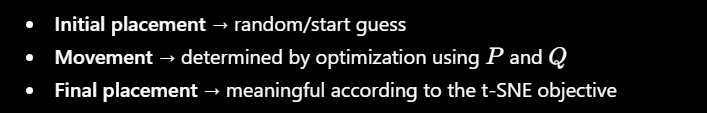

# Topic 7: KL Divergence

## 1. What is KL Divergence?

KL divergence measures **how different two probability distributions are**.

In t-SNE, we have:

$$
P=\text{similarities in high-dimensional space}
$$

and:

$$
Q=\text{similarities in low-dimensional space}
$$

We want \(Q\) to resemble \(P\).

So we minimize:

$$
KL(P\parallel Q)
$$

---

## 2. Intuition

Imagine \(P\) says:

> A and B are very similar.

So:

$$
p_{AB}=0.8
$$

But the current 2D arrangement gives:

$$
q_{AB}=0.1
$$

There is a large mismatch.

KL divergence gives a way to measure these mismatches across **all pairs of points**.

The goal is:

$$
\boxed{
KL(P\parallel Q)\rightarrow\text{as small as possible}
}
$$

---

# 3. Formula

t-SNE uses:

$$
KL(P\parallel Q)
=
\sum_i\sum_j
p_{ij}
\log
\left(
\frac{p_{ij}}{q_{ij}}
\right)
$$

Where:

* \(p_{ij}\) = high-dimensional similarity between points \(i\) and \(j\)
* \(q_{ij}\) = low-dimensional similarity
* \(\log\) = logarithm
* summation = consider all pairs of points

---

# 4. Why Compare \(P\) and \(Q\)?

Remember:

$$
P=\text{what relationships should look like}
$$

while:

$$
Q=\text{what relationships currently look like}
$$

Therefore:

$$
P
\quad\text{vs}\quad
Q
\rightarrow
KL
$$

If they are similar:

$$
KL\approx0
$$

If they are very different:

$$
KL
\text{ is larger}
$$

---

# 5. Small Numerical Example

Suppose for one pair:

$$
p_{ij}=0.5
$$

and:

$$
q_{ij}=0.5
$$

Then:

$$
p_{ij}
\log
\left(
\frac{p_{ij}}{q_{ij}}
\right)
=
0.5
\log
\left(
\frac{0.5}{0.5}
\right)
$$

Since:

$$
\frac{0.5}{0.5}=1
$$

and:

$$
\log(1)=0
$$

we get:

$$
0.5\times0=0
$$

So this pair contributes **zero** to the KL divergence.

That makes sense because:

$$
p_{ij}=q_{ij}
$$

There is no mismatch.

---

# 6. Another Example

Suppose:

$$
p_{ij}=0.8
$$

and:

$$
q_{ij}=0.2
$$

Then:

$$
0.8
\log
\left(
\frac{0.8}{0.2}
\right)
$$

$$
=
0.8\log(4)
$$

Using natural logarithm:

$$
\log(4)\approx1.386
$$

Therefore:

$$
0.8\times1.386
\approx1.109
$$

So this pair contributes approximately:

$$
1.109
$$

to the KL divergence.

That's a relatively large mismatch.

---

# 7. What if \(P\) Says Two Points Are Similar but \(Q\) Says They Are Not?

Suppose:

$$
p_{ij}=0.9
$$

and:

$$
q_{ij}=0.01
$$

Then:

$$
\frac{p_{ij}}{q_{ij}}
=
90
$$

and:

$$
\log(90)
$$

is large.

Therefore the contribution to KL divergence becomes large.

This strongly penalizes the situation:

$$
\boxed{
\text{High similarity in }P
\quad\text{but}\quad
\text{low similarity in }Q
}
$$

This is extremely important in t-SNE.

---

# 8. Why Does t-SNE Minimize KL Divergence?

Suppose initially:

$$
P\neq Q
$$

So:

$$
KL(P\parallel Q)
\text{ is large}
$$

The optimization changes the positions of the low-dimensional points.

$$
Y
\rightarrow
Y_{\text{new}}
$$

This changes \(Q\).

Then calculate KL again:

$$
Q_{\text{new}}
\rightarrow
KL(P\parallel Q_{\text{new}})
$$

If the new positions are better:

$$
KL_{\text{new}}<KL_{\text{old}}
$$

So the algorithm keeps moving the points in directions that reduce KL divergence.

---

# 9. Important Asymmetry

KL divergence is **not symmetric**.

Generally:

$$
KL(P\parallel Q)
\neq
KL(Q\parallel P)
$$

t-SNE specifically minimizes:

$$
\boxed{
KL(P\parallel Q)
}
$$

This has an important consequence.

If \(p_{ij}\) is large but \(q_{ij}\) is tiny, the penalty can be large.

So t-SNE strongly tries to preserve **important high-dimensional neighbors**.

---

# 10. Complete Role in t-SNE

At this point:

$$
\text{High-dimensional data}
\rightarrow
P
$$

and:

$$
\text{Current 2D positions}
\rightarrow
Q
$$

Then:

$$
P,Q
\rightarrow
KL(P\parallel Q)
$$

The optimization tries to make:

$$
KL(P\parallel Q)
\rightarrow
\text{minimum}
$$

So the purpose of KL divergence in t-SNE is:

$$
\boxed{
\text{Measure the mismatch between high-dimensional and low-dimensional similarities}
}
$$


**In short:**

* t-SNE considers **all pairwise relationships**.
* It calculates the **combined mismatch** through the KL-divergence gradient.
* All points can potentially move.
* **Large mismatch → stronger movement.**
* **Small mismatch → weaker movement.**

So:

$$
\boxed{
\text{All points can move, but by different amounts.}
}
$$


# Topic 8: t-SNE Workflow

## Complete Flow

$$
\text{High-dimensional Data}
\rightarrow
\text{Pairwise Distances}
\rightarrow
\text{Gaussian Similarities}
\rightarrow
P
$$

$$
\text{Initial 2D Positions}
\rightarrow
\text{Student's t Similarities}
\rightarrow
Q
$$

$$
P,Q
\rightarrow
KL(P\parallel Q)
\rightarrow
\text{Optimization}
\rightarrow
\text{Update 2D Positions}
$$

Let's understand the complete process step by step.

---

## Step 1: Start With High-Dimensional Data

Suppose we have:

$$
X=
\begin{bmatrix}
x_{11}&x_{12}&x_{13}\\
x_{21}&x_{22}&x_{23}\\
x_{31}&x_{32}&x_{33}
\end{bmatrix}
$$

Here we have:

* 3 data points
* 3 features

Our goal might be:

$$
3\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

---

## Step 2: Calculate Pairwise Distances

For every pair of points, calculate their distance.

$$
\text{Points}
\rightarrow
\text{Pairwise Distances}
$$

These distances tell us which points are close and which are far apart.

---

## Step 3: Convert Distances Into Gaussian Similarities

For each point, t-SNE uses a Gaussian distribution:

$$
s_{ij}
=
\exp
\left(
-\frac{\|x_i-x_j\|^2}
{2\sigma_i^2}
\right)
$$

Then the similarities are normalized into probabilities:

$$
p_{j|i}
=
\frac{s_{ij}}
{\sum_{k\ne i}s_{ik}}
$$

These probabilities are eventually symmetrized to produce \(P\).

So:

$$
\boxed{
\text{Distances}
\rightarrow
\text{Gaussian Similarities}
\rightarrow
P
}
$$

\(P\) represents the **desired neighborhood relationships** from the original high-dimensional data.

---

# Step 4: Initialize Low-Dimensional Points

Now t-SNE needs to place every point in 2D.

It starts with initial positions, usually small random values:

$$
Y=
\begin{bmatrix}
y_{11}&y_{12}\\
y_{21}&y_{22}\\
y_{31}&y_{32}
\end{bmatrix}
$$

These positions are just starting guesses.

They are **not the final answer**.

---

# Step 5: Calculate Low-Dimensional Similarities

Using the current 2D positions, t-SNE calculates similarities using the Student's t-distribution:

$$
q_{ij}
=
\frac{
(1+\|y_i-y_j\|^2)^{-1}
}{
\sum_{k\ne l}
(1+\|y_k-y_l\|^2)^{-1}
}
$$

This produces \(Q\).

So now we have:

$$
P=\text{desired similarities}
$$

and:

$$
Q=\text{current similarities}
$$

---

# Step 6: Compare \(P\) and \(Q\)

Calculate:

$$
KL(P\parallel Q)
=
\sum_i\sum_j
p_{ij}
\log
\left(
\frac{p_{ij}}{q_{ij}}
\right)
$$

This measures how different the current 2D representation is from the original high-dimensional relationships.

---

# Step 7: Move the Points

If the KL divergence is large, the current arrangement isn't good enough.

The optimization calculates how the points should move.

$$
Y
\rightarrow
Y_{\text{new}}
$$

For example, if two points should be close according to \(P\), but are far apart according to \(Q\), they will generally be pulled closer.

If points are too close when they shouldn't be, they can be pushed apart.

---

# Step 8: Repeat

After moving the points, calculate \(Q\) again:

$$
Y_{\text{new}}
\rightarrow
Q_{\text{new}}
$$

Then:

$$
P,Q_{\text{new}}
\rightarrow
KL(P\parallel Q_{\text{new}})
$$

Then move the points again.

So the optimization loop is:

$$
\boxed{
Y
\rightarrow
Q
\rightarrow
KL
\rightarrow
\text{Move Points}
\rightarrow
Y_{\text{new}}
\rightarrow
Q_{\text{new}}
\rightarrow
KL
\rightarrow
\cdots
}
$$

---

# Step 9: Final Embedding

After the optimization has converged sufficiently, we obtain:

$$
Y_{\text{final}}
$$

This contains the final 2D coordinates.

For example:

$$
Y_{\text{final}}=
\begin{bmatrix}
-2.1&1.3\\
-1.8&1.5\\
2.4&-0.8
\end{bmatrix}
$$

These coordinates are then plotted.

So:

$$
\boxed{
Y_{\text{final}}
\rightarrow
\text{2D t-SNE Plot}
}
$$

---

## Complete Algorithm

$$
\boxed{
X
\rightarrow
\text{Distances}
\rightarrow
P
\rightarrow
\text{Initial }Y
\rightarrow
Q
\rightarrow
KL(P\parallel Q)
\rightarrow
\text{Move }Y
\rightarrow
Q
\rightarrow
KL
\rightarrow
\cdots
\rightarrow
Y_{\text{final}}
}
$$


# Topic 10: Perplexity & Learning Rate

## 1. Perplexity

Perplexity controls the **effective size of the neighborhood** that t-SNE considers for each point.

Think of it as:

> **How many nearby points should matter when deciding the similarity around a point?**

Typical values might be:

$$
5,\ 10,\ 30,\ 50
$$

---

## 2. Why Do We Need Perplexity?

Consider two regions:

```text
Dense region:

● ● ●
 ● ●
● ● ●


Sparse region:

●        ●        ●
```

A fixed neighborhood size may not work equally well everywhere.

Perplexity helps t-SNE determine an appropriate Gaussian width:

$$
\text{Perplexity}
\rightarrow
\sigma_i
\rightarrow
\text{Gaussian similarities}
\rightarrow
P
$$

So perplexity indirectly controls how wide each point's neighborhood is.

---

# 3. Mathematical Definition

For point \(i\), suppose its conditional probabilities are:

$$
p_{j|i}
$$

The entropy is:

$$
H(P_i)
=
-\sum_j
p_{j|i}\log_2(p_{j|i})
$$

Perplexity is:

$$
\boxed{
\text{Perplexity}(P_i)
=
2^{H(P_i)}
}
$$

You don't need to calculate this manually when using Scikit-Learn.

The important intuition is:

$$
\boxed{
\text{Perplexity}
\approx
\text{effective number of neighbors}
}
$$

---

# 4. Small Example

Suppose a point has four neighbors with equal probabilities:

$$
P_i=
\begin{bmatrix}
0.25\\
0.25\\
0.25\\
0.25
\end{bmatrix}
$$

Calculate entropy:

$$
H(P_i)
=
-\sum_j p_{j|i}\log_2(p_{j|i})
$$

Since all probabilities are \(0.25\):

$$
H(P_i)
=
-4(0.25)\log_2(0.25)
$$

Since:

$$
\log_2(0.25)=-2
$$

we get:

$$
H(P_i)
=
-4(0.25)(-2)
$$

$$
=2
$$

Therefore:

$$
\text{Perplexity}
=
2^2
$$

$$
\boxed{\text{Perplexity}=4}
$$

So four equally important neighbors produce a perplexity of 4.

---

# 5. Low Perplexity

Suppose:

$$
\text{Perplexity}=5
$$

The algorithm focuses more strongly on a **small local neighborhood**.

Conceptually:

$$
\text{Low Perplexity}
\rightarrow
\text{Smaller Neighborhood}
\rightarrow
\text{More Local Detail}
$$

This can help reveal very small local structures.

But if it is too low, the result can become overly focused on tiny neighborhoods.

---

# 6. High Perplexity

Suppose:

$$
\text{Perplexity}=50
$$

The algorithm considers a **larger neighborhood**.

Conceptually:

$$
\text{High Perplexity}
\rightarrow
\text{Larger Neighborhood}
\rightarrow
\text{More Broader Structure}
$$

But if it is too high, small local structures may become less visible.

---

# 7. Perplexity Does NOT Mean Exactly This Many Neighbors

This is important.

If:

$$
\text{Perplexity}=30
$$

it does **not** mean:

> Exactly 30 nearest neighbors are selected.

It is an **effective neighborhood size** derived from the probability distribution.

So think:

$$
\boxed{
\text{Perplexity}\approx\text{neighborhood scale}
}
$$

rather than:

$$
\text{Perplexity}=\text{exact number of neighbors}
$$

---

# 8. Learning Rate

Now we have another important parameter:

$$
\boxed{\eta}
$$

called the **learning rate**.

It controls:

> **How much the low-dimensional points move during each optimization step.**

Recall the gradient-descent update:

$$
Y_{\text{new}}
=
Y_{\text{old}}
-
\eta
\nabla_Y KL(P\parallel Q)
$$

Here:

$$
\eta=\text{learning rate}
$$

---

# 9. Small Learning Rate

Suppose:

$$
\eta=0.01
$$

The points move only a small amount at each iteration.

Conceptually:

$$
\text{Small }\eta
\rightarrow
\text{Small Updates}
\rightarrow
\text{Slow Optimization}
$$

It may take many iterations to reach a good arrangement.

---

# 10. Large Learning Rate

Suppose:

$$
\eta=100
$$

The points can move much more during each iteration.

Conceptually:

$$
\text{Large }\eta
\rightarrow
\text{Large Updates}
$$

If it is excessively large, optimization can become unstable or produce poor results.

---

# 11. Numerical Example

Suppose:

$$
y=5
$$

and:

$$
\nabla KL=2
$$

### Learning rate = 0.1

$$
y_{\text{new}}
=
5-(0.1)(2)
$$

$$
=4.8
$$

The point moves:

$$
5\rightarrow4.8
$$

### Learning rate = 1

$$
y_{\text{new}}
=
5-(1)(2)
$$

$$
=3
$$

Now the point moves much more:

$$
5\rightarrow3
$$

So:

$$
\boxed{
\eta\text{ controls the step size}
}
$$

---

# 12. Perplexity vs Learning Rate

These two parameters control **different things**.

### Perplexity

Controls the neighborhood scale:

$$
\boxed{
\text{Perplexity}
\rightarrow
\text{How broadly similarities are considered}
}
$$

### Learning rate

Controls optimization movement:

$$
\boxed{
\text{Learning Rate}
\rightarrow
\text{How far points move per update}
}
$$

Don't confuse them.

---

# 13. Scikit-Learn

In Scikit-Learn:

```python
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    random_state=42
)
```

Here:

* `n_components=2` → create a 2D embedding
* `perplexity=30` → neighborhood scale
* `learning_rate="auto"` → let Scikit-Learn determine the learning rate
* `random_state=42` → make the random initialization reproducible

The overall effect is:

$$
\text{Perplexity}
\rightarrow
\text{controls neighborhood}
$$

$$
\text{Learning Rate}
\rightarrow
\text{controls movement during optimization}
$$


### I not undertstand what it mean 10 point around it or whar?

Suppose you have **100 points** in your dataset, and we are looking at one particular point **A**.

If:

$$
\text{Perplexity}=10
$$

then t-SNE is roughly saying:

> **"For point A, I want the neighborhood to behave as though about 10 nearby points are important."**

Imagine the points ordered by distance from A:

```text
A → closest
    ●  Point 1
    ●  Point 2
    ●  Point 3
    ●  Point 4
    ●  Point 5
    ●  Point 6
    ●  Point 7
    ●  Point 8
    ●  Point 9
    ●  Point 10
    ●  Point 11
    ●  Point 12
    ...
```

With perplexity around 10, **the first ~10 nearby points have the most important influence**, but point 11, 12, etc. are **not suddenly ignored**.

Their probabilities gradually become smaller as their distance increases.

So don't imagine a hard boundary like DBSCAN:

$$
\boxed{\text{Perplexity}=10\neq\text{maximum 10 neighbors}}
$$

Instead imagine:

$$
\boxed{
\text{Perplexity}=10
\approx
\text{a neighborhood of about 10 effective neighbors}
}
$$

### The easiest way to remember it

**DBSCAN:**

> "Within this distance, who are my neighbors?"

**t-SNE:**

> "Around this point, how broad should the neighborhood of important points be?"

So **yes, "around 10 points" is a good intuition**, as long as you remember that it is **not a strict cutoff**.


# Topic 11: Scikit-Learn — t-SNE

## 1. Import

```python
from sklearn.manifold import TSNE
```

`TSNE` is Scikit-Learn's implementation of t-SNE.

---

## 2. Creating t-SNE

```python
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    random_state=42
)
```

This creates the t-SNE algorithm.

### `n_components`

Controls the number of dimensions in the output.

```python
n_components=2
```

means:

$$
\text{High-dimensional data}
\rightarrow
2\text{ dimensions}
$$

So every final point will have two coordinates:

$$
\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}
$$

---

### `perplexity`

Controls the effective neighborhood size.

```python
perplexity=30
```

means roughly:

> Consider a neighborhood behaving like about 30 important nearby points.

It is **not a hard limit of 30 neighbors**.

---

### `learning_rate`

Controls how much the points move during optimization.

```python
learning_rate="auto"
```

means Scikit-Learn automatically chooses a suitable value.

Conceptually:

$$
\text{Learning Rate}
\rightarrow
\text{Step Size During Optimization}
$$

---

### `random_state`

```python
random_state=42
```

t-SNE uses randomness during initialization.

Setting `random_state` makes the result **reproducible**.

For example, running the same code again with the same settings will give the same result.

---

# 3. Fitting and Transforming

Unlike PCA, we commonly use:

```python
X_tsne = tsne.fit_transform(X)
```

This does two things:

$$
\text{fit}
\rightarrow
\text{Run the t-SNE optimization}
$$

and:

$$
\text{transform}
\rightarrow
\text{Return the final low-dimensional coordinates}
$$

The result might look like:

$$
X_{\text{t-SNE}}=
\begin{bmatrix}
-12.4&8.2\\
-10.1&7.5\\
15.3&-4.1\\
14.8&-5.2
\end{bmatrix}
$$

Each row corresponds to one original observation.

---

# 4. Important Difference From PCA

With PCA, we can do:

```python
pca.fit(X)
```

and later:

```python
pca.transform(X_new)
```

t-SNE is generally used differently.

It is primarily a **visualization/embedding technique**, rather than a transformation pipeline intended to project future unseen samples using a learned fixed mapping.

So the common usage is:

```python
X_tsne = tsne.fit_transform(X)
```

---

The complete practical flow is:

$$
X
\rightarrow
\text{TSNE}
\rightarrow
\text{fit\_transform}
\rightarrow
X_{\text{t-SNE}}
\rightarrow
\text{2D Plot}
$$


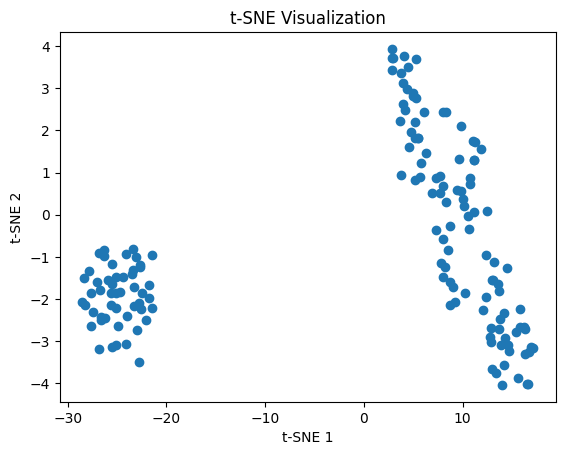

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Create t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    random_state=42
)

# Perform t-SNE and obtain 2D coordinates
X_tsne = tsne.fit_transform(X)

# Plot the resulting 2D embedding
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1]
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")

plt.show()

# Topic 12: Visualization

After t-SNE finishes optimization, we get a low-dimensional matrix containing the final coordinates of every point.

If:

$$
X_{\text{t-SNE}}=
\begin{bmatrix}
y_{11}&y_{12}\\
y_{21}&y_{22}\\
y_{31}&y_{32}
\end{bmatrix}
$$

then:

* column 1 → t-SNE dimension 1
* column 2 → t-SNE dimension 2

We simply plot these two columns.

```python
import matplotlib.pyplot as plt

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1]
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")

plt.show()
```

## With Class Labels

If `y` contains class labels, we can plot each class separately:

```python
plt.figure()

plt.scatter(
    X_tsne[y == 0, 0],
    X_tsne[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_tsne[y == 1, 0],
    X_tsne[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_tsne[y == 2, 0],
    X_tsne[y == 2, 1],
    label="Class 2"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")
plt.legend()

plt.show()
```

Here:

```python
X_tsne[y == 0, 0]
```

means:

> Take the **first t-SNE coordinate** of all Class 0 points.

And:

```python
X_tsne[y == 0, 1]
```

means:

> Take the **second t-SNE coordinate** of all Class 0 points.

Therefore:

$$
\text{x-axis}=\text{t-SNE dimension 1}
$$

$$
\text{y-axis}=\text{t-SNE dimension 2}
$$

---

## How to Interpret the Plot

If several points appear close together:

$$
\text{Close points}
\rightarrow
\text{Similar local neighborhoods}
$$

If groups of points form visible clusters, this suggests that t-SNE found distinct local structures in the original high-dimensional data.

However, **do not interpret the exact distance between clusters too strongly**.

For example:

```text
Cluster A ● ● ●


                 Cluster B ● ● ●
```

You cannot conclude:

> "Cluster B is exactly twice as different from A as another cluster."

t-SNE is primarily trying to preserve **local relationships**, not global distances.

### Most important interpretation

$$
\boxed{
\text{Nearby points in the t-SNE plot}
\rightarrow
\text{likely similar in the original space}
}
$$

But:

$$
\boxed{
\text{Distance between separate clusters}
\not\rightarrow
\text{reliable quantitative similarity}
}
$$


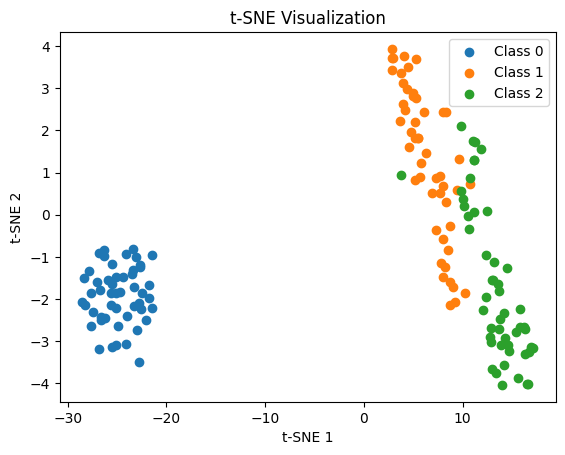

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Create t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    random_state=42
)

# Perform t-SNE and obtain 2D coordinates
X_tsne = tsne.fit_transform(X)

plt.figure()

plt.scatter(
    X_tsne[y == 0, 0],
    X_tsne[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_tsne[y == 1, 0],
    X_tsne[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_tsne[y == 2, 0],
    X_tsne[y == 2, 1],
    label="Class 2"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")
plt.legend()

plt.show()

It helps you understand **whether the high-dimensional data has meaningful groups or local patterns** that you couldn't see directly.

For example, suppose you have customer data with 100 features.

After t-SNE you see:

```text
       ● ● ●
      ● ● ●
       ● ●

                         ● ● ●
                        ● ● ●
                         ● ●
```

You might discover **two distinct groups of customers**.

### Why is that useful?

You can then investigate the original data for those groups:

$$
\text{t-SNE}
\rightarrow
\text{Discover Groups}
\rightarrow
\text{Go back to Original Features}
\rightarrow
\text{Understand Why Groups Differ}
$$

For example:

* Group 1 → younger customers with low spending
* Group 2 → older customers with high spending

t-SNE didn't tell you **why** they are different. It helped you **notice that a structure exists**.

### Common uses

* 🔍 **Exploratory data analysis** — discover hidden patterns
* 🧬 **Biology** — see groups of similar cells/genes
* 🖼️ **Images** — see whether similar images group together
* 📝 **Text** — visualize groups of similar documents/embeddings
* 🤖 **ML debugging** — see whether your learned representations contain meaningful structure

So the main value is:

$$
\boxed{
\text{High-dimensional data is hard to see}
\rightarrow
\text{t-SNE makes local structure visible}
}
$$

It's primarily a **discovery/visualization tool**, not a tool that directly tells you the cause of the clusters.


After t-SNE, mainly look for **local groups/clusters**.

### What you want to see

If the plot looks like:

```text
        ● ● ●
       ● ● ●
        ● ●


                    ● ● ●
                   ● ● ●
                    ● ●
```

You can say:

* Points close together → **likely similar in the original high-dimensional space**
* Clearly separated groups → **different local structures may exist**
* Mixed points → those points have similar local relationships

### But don't interpret this:

```text
Cluster A ● ● ●                    Cluster B ● ● ●
```

as:

> "A and B are exactly this far apart."

The **distance between separate clusters is not reliably meaningful in t-SNE**.

### Most important thing

$$
\boxed{
\text{Look at who is close to whom, not exact global distances.}
}
$$

So when you see a t-SNE plot, ask:

1. **Are there visible groups?**
2. **Are points within each group close?**
3. **Do nearby points make sense based on the original data?**
4. **Does the pattern remain reasonably similar with different perplexity/random seeds?**


# Topic 14: Advantages, Limitations & Suitable Data Shapes

## Advantages

### 1. Excellent for Visualization

t-SNE can reduce:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

making complex high-dimensional relationships visually understandable.

### 2. Preserves Local Structure

Its biggest strength is preserving **nearby relationships**:

$$
\text{Similar points}
\rightarrow
\text{Remain close}
$$

This can reveal clusters that PCA may not clearly show.

### 3. Captures Nonlinear Structure

Unlike PCA, t-SNE can represent nonlinear relationships.

$$
\boxed{\text{PCA → Linear}}
$$

$$
\boxed{\text{t-SNE → Nonlinear}}
$$

---

# Limitations

### 1. Mainly for Visualization

t-SNE is generally not the first choice when you need a general-purpose feature transformation for another ML model.

### 2. Computationally Expensive

For large datasets, t-SNE can require significant computation.

### 3. Sensitive to Parameters

Changing:

```python
perplexity
learning_rate
random_state
```

can change the resulting visualization.

### 4. Global Distances Are Not Reliable

If two clusters are far apart:

$$
\text{Cluster A}\qquad\qquad\text{Cluster B}
$$

you cannot conclude that their exact distance represents how different the clusters are.

### 5. Randomness

Different initializations can produce different layouts.

The exact coordinates are therefore not inherently meaningful.

---

# Suitable Data Shapes

t-SNE accepts data in the form:

$$
X\in\mathbb{R}^{n\times d}
$$

where:

* \(n\) = number of samples
* \(d\) = number of features

For example:

$$
X=
\begin{bmatrix}
x_{11}&x_{12}&x_{13}&x_{14}\\
x_{21}&x_{22}&x_{23}&x_{24}\\
x_{31}&x_{32}&x_{33}&x_{34}
\end{bmatrix}
$$

Here:

$$
n=3,\qquad d=4
$$

So there are **3 samples with 4 features each**.

---

## When t-SNE Is Suitable

t-SNE is particularly useful when:

* You have **high-dimensional numerical data**
* You want to visualize the data in 2D/3D
* You suspect hidden clusters or local structures
* You are working with embeddings, images, text representations, biological data, etc.

Typical flow:

$$
\text{High-dimensional Data}
\rightarrow
\text{t-SNE}
\rightarrow
2D/3D
\rightarrow
\text{Visualization}
$$

### Main mental model

$$
\boxed{
\text{t-SNE = visualize high-dimensional local structure}
}
$$

It is powerful for **exploration**, but its plots should not be treated as proof of global cluster structure or precise distances.
